In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path


In [2]:
# conecta a la base de datos mercado_inmobiliario.db y carga la tabla llamada tablon_analitico
import sqlite3

conn = sqlite3.connect('../datos/intermedios/mercado_inmobiliario.db')
query = "SELECT * FROM tablon_analitico"
df = pd.read_sql_query(query, conn)
conn.close()

In [3]:
dimensiones = ['distrito', 'neighbourhood', 'room_type', 'bedrooms_disc', 'accommodates_disc', 'beds_disc']

metricas = ['precio_noche_total', 'estimated_occupancy_l365d', 'ingreso_anual', 'coste_adquisicion','margen_bruto']

In [4]:
# Paso 1: Seleccionar dimensiones y métricas
minicubo = df[dimensiones + metricas]

In [5]:
# Paso 2: Pasar a transaccional las dimensiones
minicubo = minicubo.melt(id_vars=metricas, value_vars=dimensiones)

In [6]:
# Paso 3: Agregar las métricas por "variable" y "valor"
minicubo_agg = minicubo.groupby(['variable', 'value'])[metricas].median().reset_index()
minicubo_agg

,variable,value,precio_noche_total,estimated_occupancy_l365d,ingreso_anual,coste_adquisicion,margen_bruto
0,accommodates_disc,01_Uno,41.0,66.0,2964.0,220012.50,1.460
1,accommodates_disc,02_Dos,81.0,104.0,7650.0,273037.50,3.460
2,accommodates_disc,03_Tres,100.0,112.0,10323.0,273037.50,4.305
3,accommodates_disc,04_Cuatro,125.0,102.0,12600.0,273037.50,4.720
4,accommodates_disc,05_Mas_de_Cuatro,179.0,120.0,20508.0,354948.75,5.415
...,...,...,...,...,...,...,...
159,neighbourhood,Vista Alegre,59.0,96.0,3507.0,126187.50,2.780
160,neighbourhood,Zofío,63.0,33.0,2088.0,117337.50,1.730
161,room_type,Entire home/apt,120.0,114.0,13910.0,273037.50,4.990
162,room_type,Private room,49.0,78.0,3864.0,225412.50,1.855


## ANÁLISIS DE RENTABILIDAD

Insights análisis rentabilidad (Inmuebles más rentables):
* 2 o 3 habitaciones
* Con 4 o más personas
* Distritos no típicos: Villa de Vallecas, Barajas, Moratalaz, Puente de Vallecas
* Alquiler de todo el apartamento
* Los de ese perfil con ocupación > 200 días tienen rentabilidades del 8% al 20%

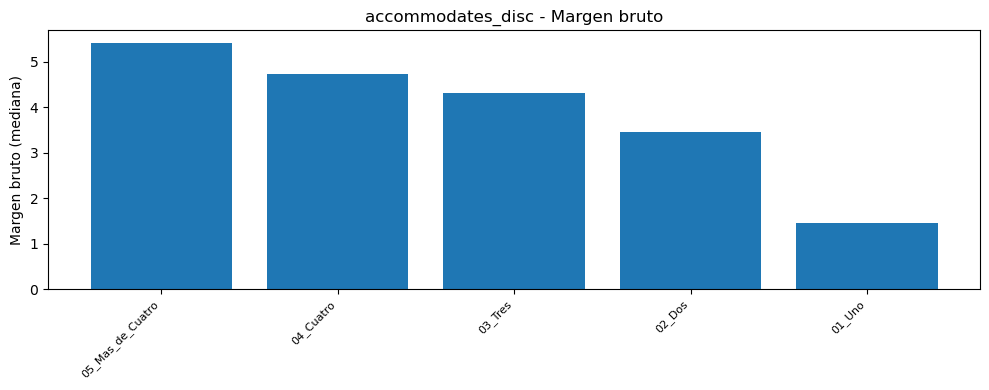

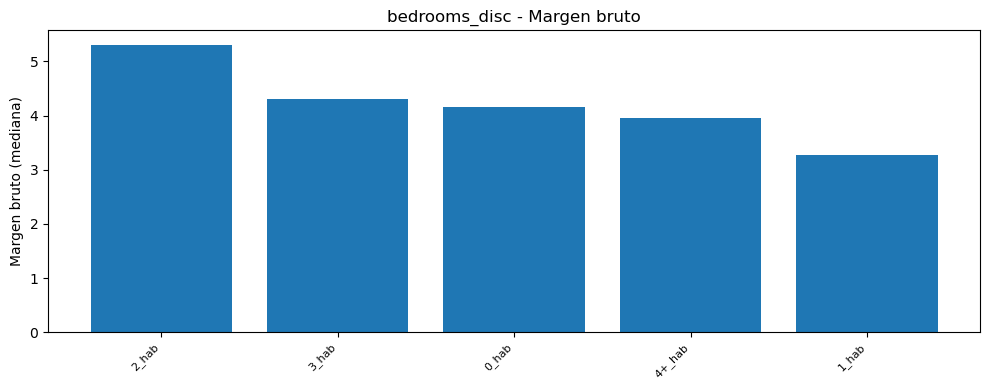

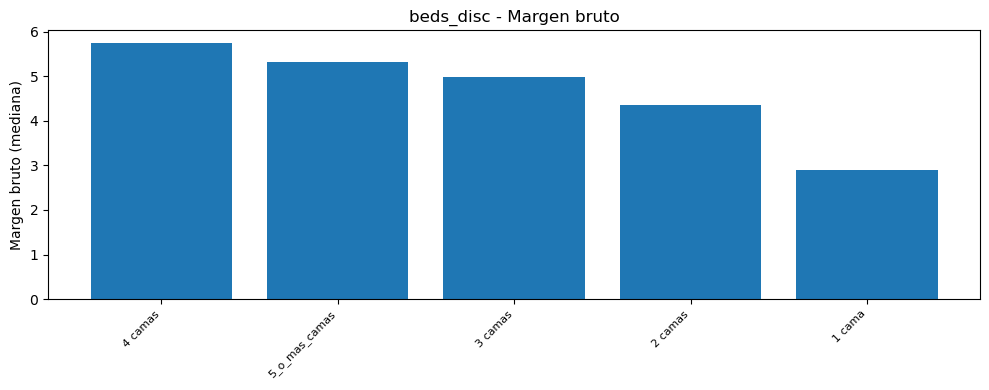

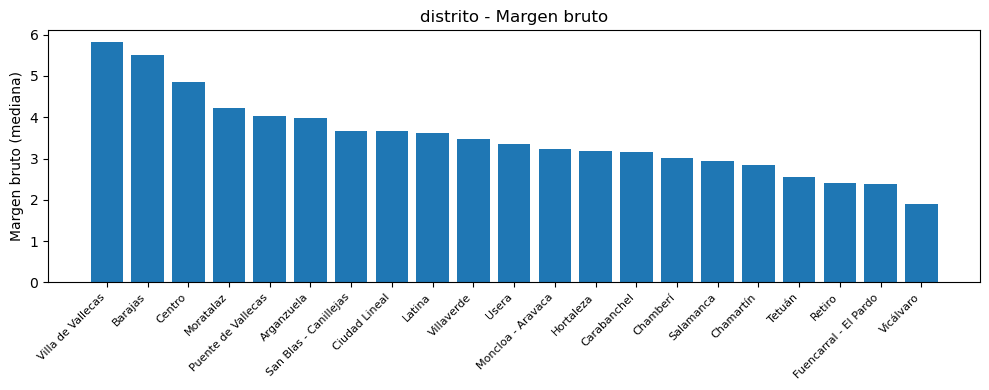

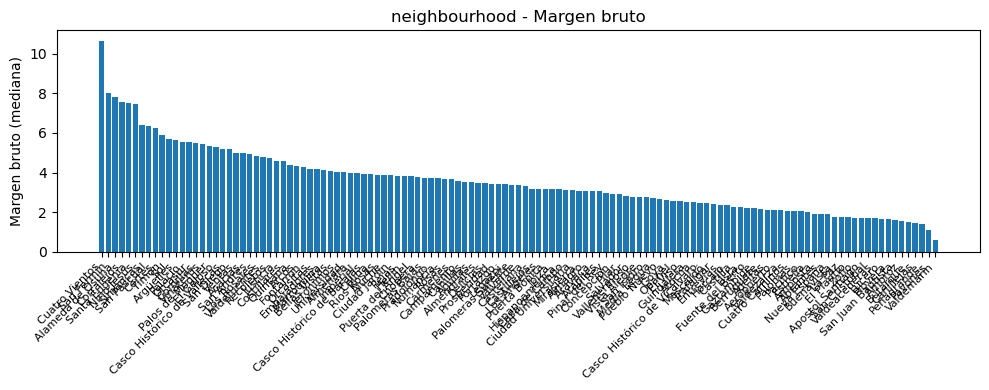

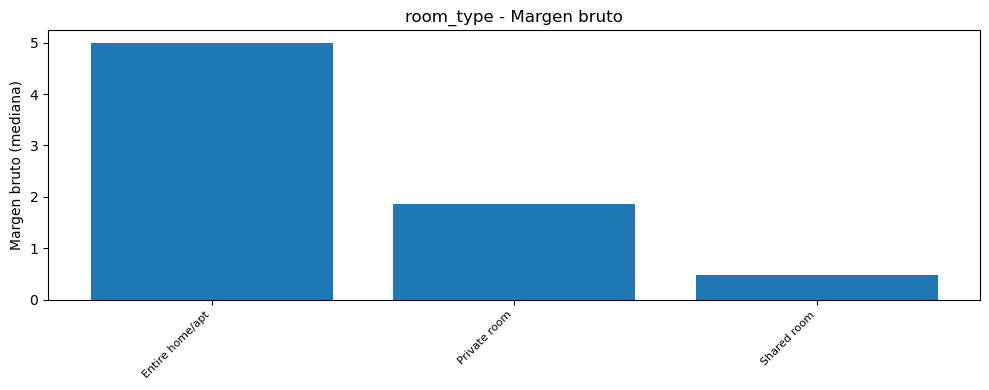

In [7]:
for dimension in minicubo_agg['variable'].unique():
    datos = minicubo_agg[minicubo_agg['variable'] == dimension].sort_values('margen_bruto', ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(datos['value'], datos['margen_bruto'])
    plt.title(f"{dimension} - Margen bruto")
    plt.ylabel("Margen bruto (mediana)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

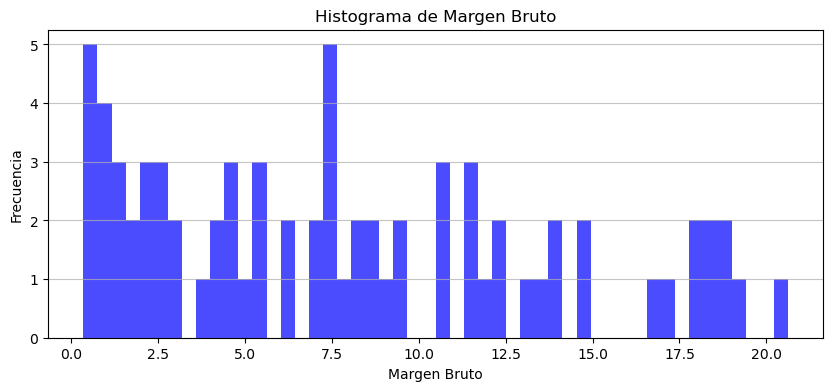

In [10]:
# filtra registros donde: 2 o 3 habitaciones, 4 o más personas, distritos: Villa de Vallecas, Barajas, Moratalaz, Puente de Vallecas, alquiler de todo el apartamento
df_temp = df[
    (df['bedrooms_disc'].isin(['2_hab', '3_hab'])) &
    (df['accommodates_disc'].isin(['04_Cuatro', '05_Mas_de_Cuatro'])) &
    (df['distrito'].isin(['Villa de Vallecas', 'Barajas', 'Moratalaz', 'Puente de Vallecas'])) &
    (df['room_type'] == 'Entire home/apt')
]

# historgrama de margen_bruto
plt.figure(figsize=(10, 4))
plt.hist(df_temp['margen_bruto'], bins=50, color='blue', alpha=0.7)
plt.title("Histograma de Margen Bruto")
plt.xlabel("Margen Bruto")
plt.ylabel("Frecuencia")
plt.grid(axis='y', alpha=0.75)
plt.show()

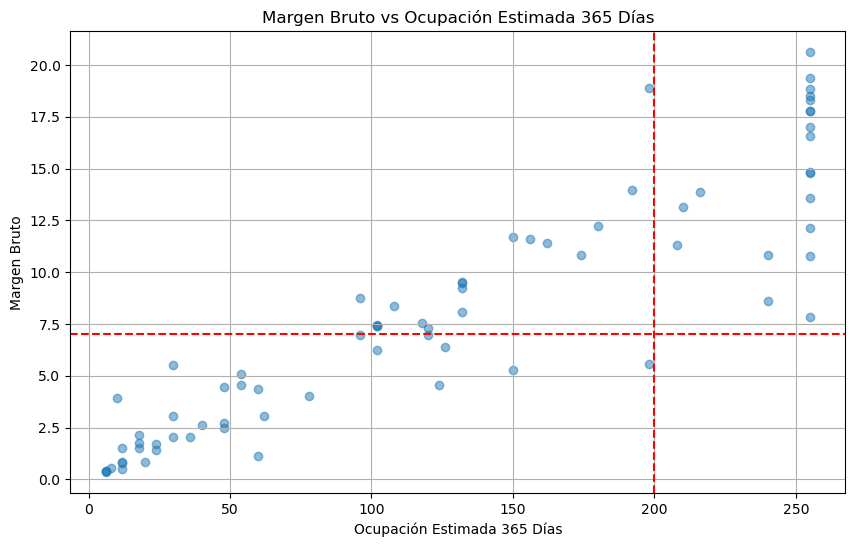

In [11]:
# superponer un recuadro sobre el scatter plot donde estimated_occupancy_l365d > 200 y margen_bruto > 7
plt.figure(figsize=(10, 6))
plt.scatter(df_temp['estimated_occupancy_l365d'], df_temp['margen_bruto'], alpha=0.5)
plt.title("Margen Bruto vs Ocupación Estimada 365 Días")
plt.xlabel("Ocupación Estimada 365 Días")
plt.ylabel("Margen Bruto")
plt.grid()

# Recuadro
plt.axhline(y=7, color='r', linestyle='--')
plt.axvline(x=200, color='r', linestyle='--')
plt.show()

## ANÁLISIS DE OCUPACIÓN

Insights análisis ocupación (Inmuebles con mayor ocupación):
* 4 o más habitaciones
* Con 5 o más personas
* Especial interés en Barajas, es posible comprar inmuebles con ocupacion superior a 200 días y rentabilidad superior al 10% por menos de 200.000€

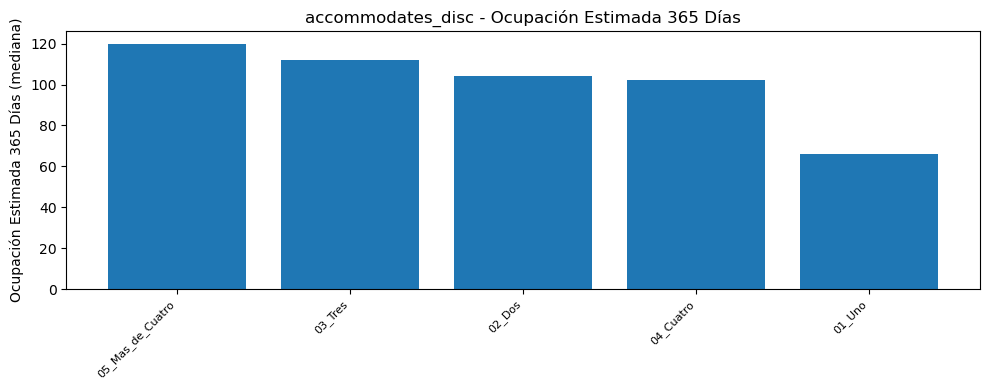

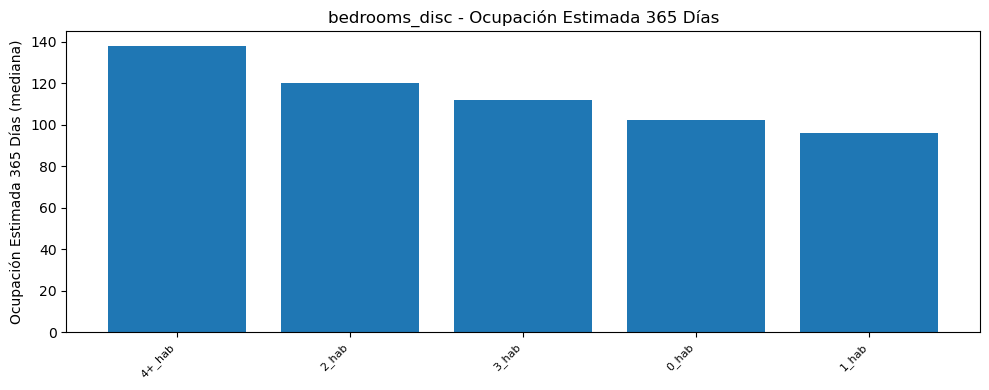

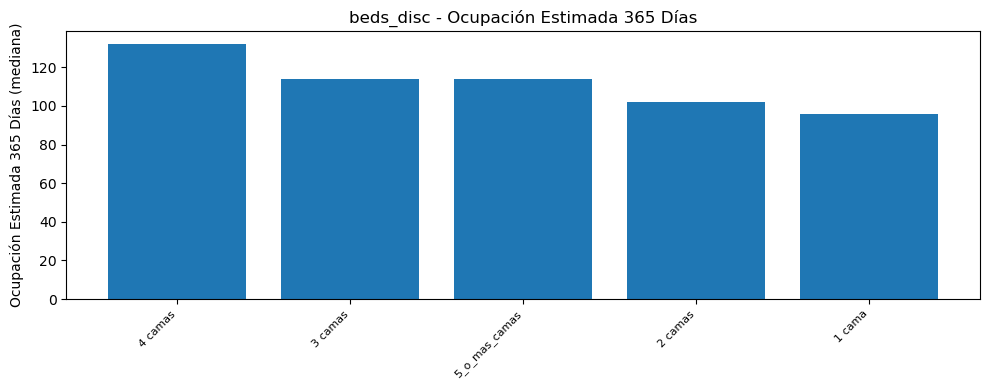

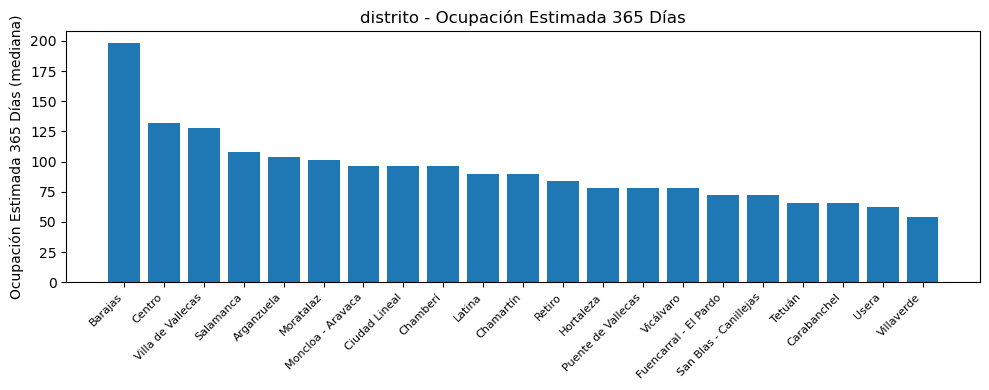

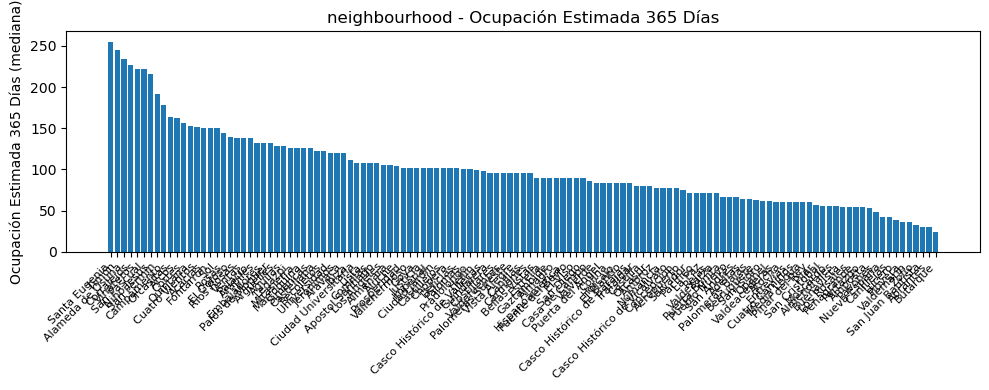

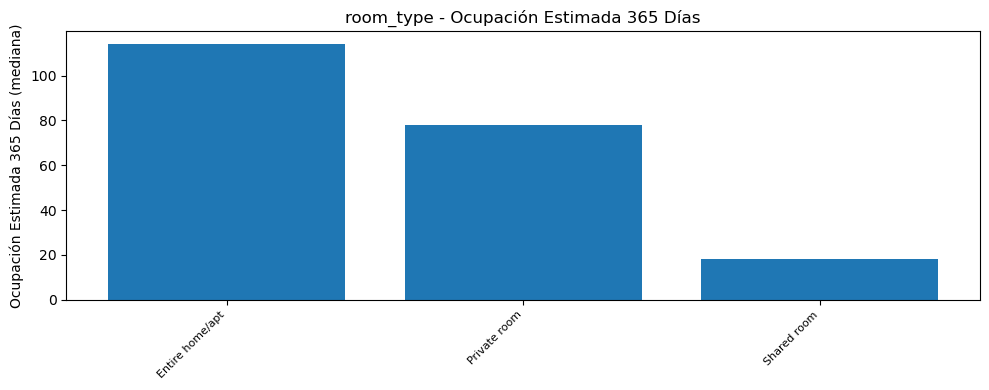

In [12]:
for dimension in minicubo_agg['variable'].unique():
    datos = minicubo_agg[minicubo_agg['variable'] == dimension].sort_values('estimated_occupancy_l365d', ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(datos['value'], datos['estimated_occupancy_l365d'])
    plt.title(f"{dimension} - Ocupación Estimada 365 Días")
    plt.ylabel("Ocupación Estimada 365 Días (mediana)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

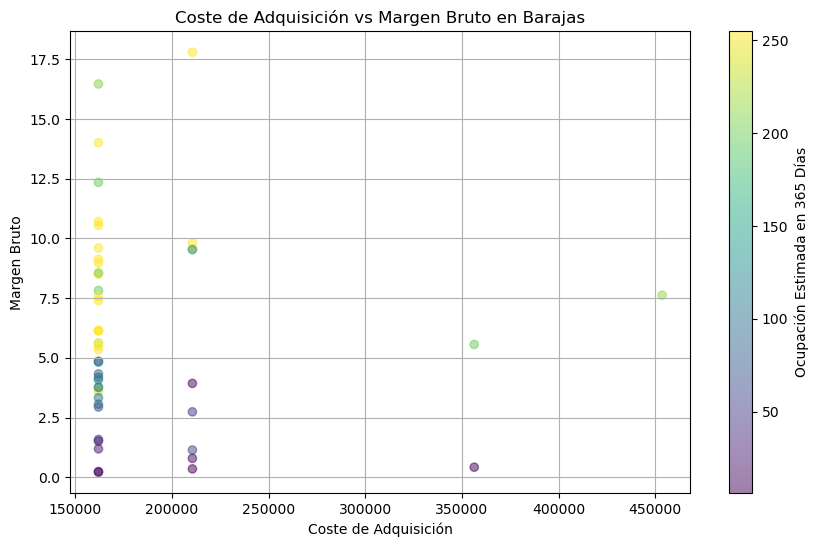

In [13]:
# crear un df_barajas con los registros de df donde distrito es Barajas
df_barajas = df[df['distrito'] == 'Barajas']

# crea un scatter plot de coste_adquisicion vs margen_bruto y la ocupación estimada en 365 días como color del punto
plt.figure(figsize=(10, 6))
plt.scatter(df_barajas['coste_adquisicion'], df_barajas['margen_bruto'], c=df_barajas['estimated_occupancy_l365d'], cmap='viridis', alpha=0.5)
plt.title('Coste de Adquisición vs Margen Bruto en Barajas')
plt.xlabel('Coste de Adquisición')
plt.ylabel('Margen Bruto')
plt.grid()
plt.colorbar(label='Ocupación Estimada en 365 Días')
plt.show()

## DONDE COMPRAR

* Los 3 distritos principales a explorar son: Villa de Vallecas, Barajas y Centro
* Aunque pueden encontradas oportunidades atípicas de alta rentabilidad en casi cualquier distrito

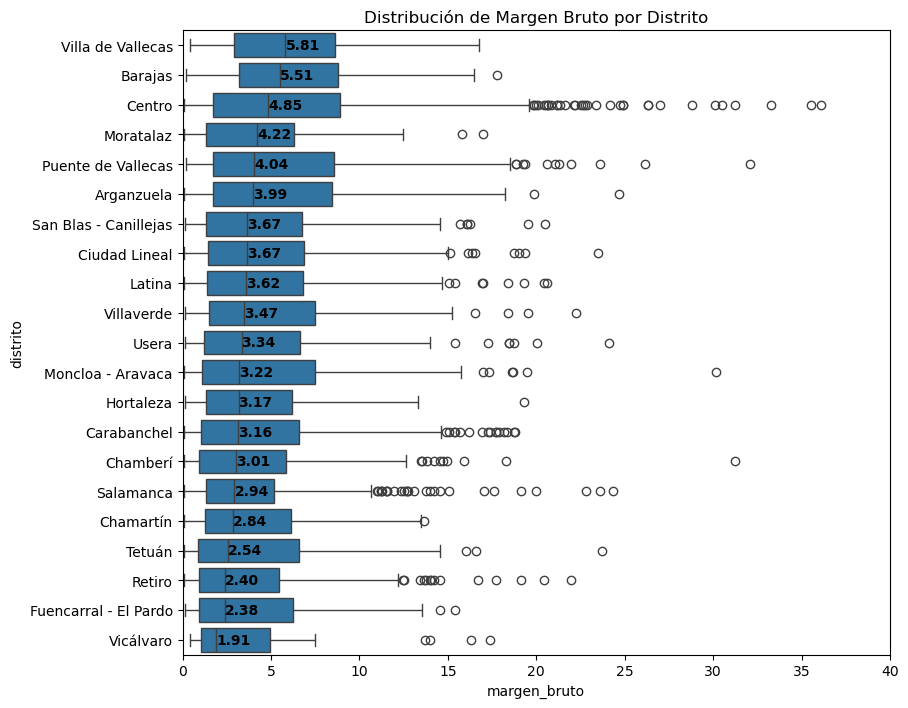

In [14]:
# boxplot horizontal de margen_bruto por distrito con etiquetas de la mediana en cada barra y límite en el eje x
plt.figure(figsize=(10, 8))
ax = sns.boxplot(
    y='distrito',
    x='margen_bruto',
    data=df,
    order=df.groupby('distrito')['margen_bruto'].median().sort_values(ascending=False).index
)
plt.title('Distribución de Margen Bruto por Distrito')
plt.yticks(rotation=0)
plt.xlim(0, 40)
plt.tight_layout(pad=4)

# Añadir etiquetas de la mediana en cada barra
medianas = df.groupby('distrito')['margen_bruto'].median()
for i, label in enumerate(ax.get_yticklabels()):
    valor_mediana = medianas[label.get_text()]
    ax.text(valor_mediana, i, f"{valor_mediana:.2f}", va='center', ha='left', color='black', fontweight='bold')

plt.show()


### NIVEL 1: ¿Qué comprar en Villa de Vallecas, Barajas, Centro?

* Bien 2 habitaciones o bien 4 o más 
* Comprar solo para alquiler del piso completo excepto en Barajas donde es mejor comprar para habitaciones

In [15]:
# crea un df solo con los registros de Villa de Vallecas, Barajas, Centro
distritos_interes = ['Villa de Vallecas', 'Barajas', 'Centro']
df_seleccion = df[df['distrito'].isin(distritos_interes)]

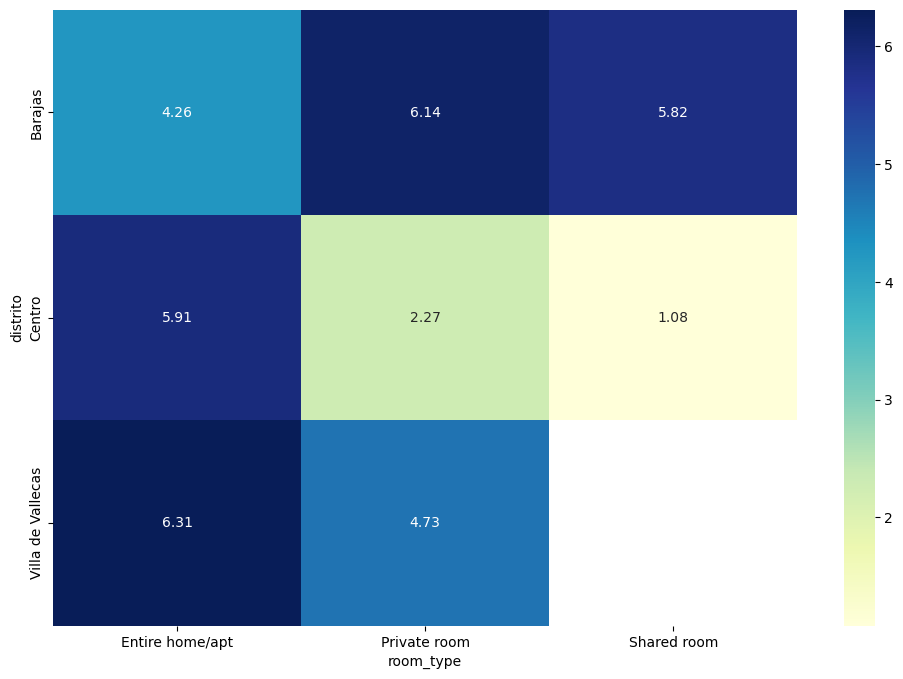

In [16]:
# crea sobre df un mapa de calor con el margen_bruto
plt.figure(figsize=(12, 8))
pivot_table = df_seleccion.pivot_table(values='margen_bruto', index='distrito', columns='room_type', aggfunc='median')
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlGnBu');

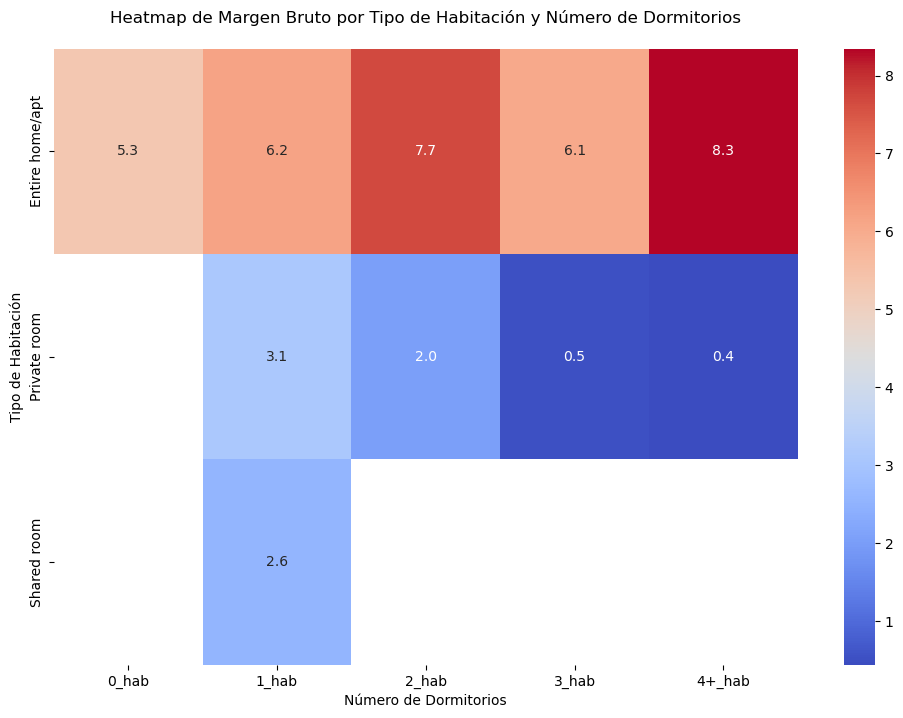

In [17]:
# crea un heatmap con el margen_bruto por room_type u bedrooms_disc
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_seleccion.pivot_table(
        index='room_type',
        columns='bedrooms_disc',
        values='margen_bruto',
        aggfunc='mean'
    ),
    cmap='coolwarm',
    annot=True,
    fmt=".1f"
)
plt.title('Heatmap de Margen Bruto por Tipo de Habitación y Número de Dormitorios\n')
plt.xlabel('Número de Dormitorios')
plt.ylabel('Tipo de Habitación')
plt.show()

### NIVEL 2: ¿Qué comprar en el resto de distritos?

* 3 habitaciones en Puente de Vallecas
* 2 habitaciones en Villa de Vallecas
* 3 habitaciones en Villaverde
* 4 o más habitaciones en Ciudad Lineal
* Investigar 0 habitacione en Moratalaz
* En todos ellos para alquiler del piso completo y que se puedan acomodar 4 o más personas

In [18]:
# sobre df filtra solo los que son Entire home/apt y que no son de distritos Villa de Vallecas, Barajas, Centro
df_seleccion = df[df['room_type'] == 'Entire home/apt']
df_seleccion = df_seleccion[~df_seleccion['distrito'].isin(['Villa de Vallecas', 'Barajas', 'Centro'])]

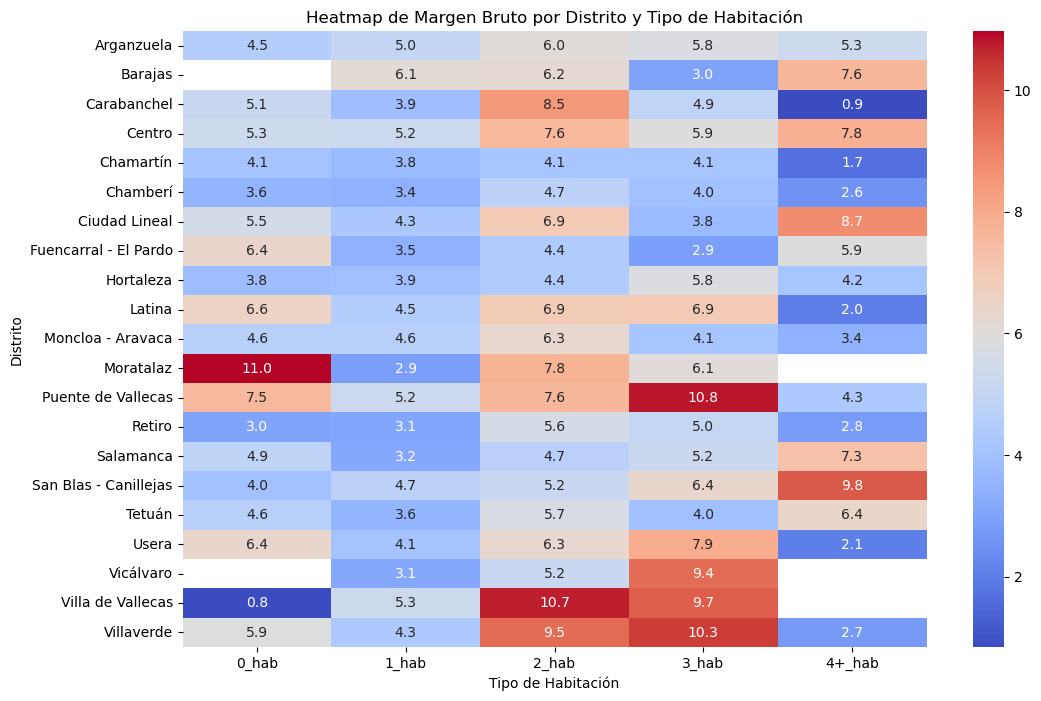

In [19]:
 # crea un heatmap con el margen_bruto por distrito y bedrooms_disc
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.pivot_table(
        index='distrito',
        columns='bedrooms_disc',
        values='margen_bruto',
        aggfunc='mean'
    ),
    cmap='coolwarm',
    annot=True,
    fmt=".1f"
)
plt.title('Heatmap de Margen Bruto por Distrito y Tipo de Habitación')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Distrito')
plt.show()

### NIVEL 3: Análisis por barrios

In [20]:
# agrupa por distrito, neighbourhood, bedrooms_disc, accommodates_disc y calcula la mediana de margen_brutoy estimated_occupancy_l365d
df_grouped = df_seleccion.groupby(['distrito', 'neighbourhood', 'bedrooms_disc', 'accommodates_disc']).agg({
    'margen_bruto': 'median',
    'estimated_occupancy_l365d': 'median'
}).reset_index()

# ordena por margen_bruto descendente y muestra los 20 primeros
df_grouped.sort_values(by='margen_bruto', ascending=False).head(20)

,distrito,neighbourhood,bedrooms_disc,accommodates_disc,margen_bruto,estimated_occupancy_l365d
694,Usera,Moscardó,0_hab,05_Mas_de_Cuatro,24.110,246.0
584,Salamanca,Recoletos,4+_hab,05_Mas_de_Cuatro,22.810,255.0
709,Usera,Orcasur,3_hab,05_Mas_de_Cuatro,20.050,255.0
390,Moncloa - Aravaca,Argüelles,1_hab,05_Mas_de_Cuatro,19.460,255.0
348,Latina,Aguilas,1_hab,05_Mas_de_Cuatro,19.310,192.0
505,Retiro,Jerónimos,4+_hab,05_Mas_de_Cuatro,19.120,240.0
451,Puente de Vallecas,Palomeras Bajas,1_hab,04_Cuatro,18.915,238.5
108,Carabanchel,San Isidro,2_hab,04_Cuatro,18.760,228.0
231,Ciudad Lineal,Colina,2_hab,04_Cuatro,18.740,255.0
445,Puente de Vallecas,Numancia,2_hab,04_Cuatro,18.510,255.0


## ANÁLISIS GEOGRÁFICO

Nota: si al intentar ejecutar el mapa te da un error de que tienes que hacer trust en el notebook y no tienes botón pon esto en la terminal:

jupyter trust "c:\Users\isaac\Google Drive\DS4B\CursoMachineLearningPython2\Casos\BA\AnalisisMercadoInmobiliario\04_Plataforma\Caso1_AnalisisMercadoInmobiliario\notebooks\03_Analisis.ipynb" (cambia la ruta por la tuya)

### Mapa de calor de rentabilidad (margen_bruto)

In [23]:
import folium
from folium.plugins import HeatMap

# Asegúrate de tener las columnas 'latitude' y 'longitude' en df
df_map = df.dropna(subset=['latitude', 'longitude', 'margen_bruto'])
madrid_coords = [40.4168, -3.7038]
m = folium.Map(location=madrid_coords, zoom_start=11)

heat_data = [[row['latitude'], row['longitude'], row['margen_bruto']] for idx, row in df_map.iterrows()]
HeatMap(heat_data, radius=8, blur=15, max_zoom=1).add_to(m)

from IPython.display import display
display(m)

m.save('../entregables/graficos/mapa_rentabilidad.html')

### Mapa de ocupación

In [24]:
m2 = folium.Map(location=madrid_coords, zoom_start=11)
heat_data2 = [[row['latitude'], row['longitude'], row['estimated_occupancy_l365d']] for idx, row in df_map.iterrows()]
HeatMap(heat_data2, radius=8, blur=15, max_zoom=1).add_to(m2)

display(m2)

m2.save('../entregables/graficos/mapa_ocupacion.html')

#### Mapa de oportunidades (alta rentabilidad y ocupación)

In [25]:
df_oportunidades = df_map[(df_map['margen_bruto'] > 20) & (df_map['estimated_occupancy_l365d'] > 200)]
m3 = folium.Map(location=madrid_coords, zoom_start=11)
for _, row in df_oportunidades.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color='blue',
        fill=True,
        fill_color='yellow',
        popup=f"Barrio: {row['neighbourhood']}<br>Rentabilidad: {row['margen_bruto']:.2f}<br>Ocupación: {row['estimated_occupancy_l365d']}",
    ).add_to(m3)

display(m3)

m3.save('../entregables/graficos/mapa_oportunidades.html')